## Theory
Artificial Neural Networks (ANNs) are computational models inspired by the structure and functioning of biological neurons. A neural network consists of interconnected layers of neurons that learn patterns from data through training.

The given model:

```python
    class LinearRegressionNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = nn.Linear(
                in_features=1,
                out_features=1,
                bias=True
            )

        def forward(self, x):
            return self.linear(x)
```
contains a single fully connected (linear) layer. The model learns a relationship of the form:

y = wx + b

where:
- x = input feature
- y = predicted output
- w = weight parameter
- b = bias parameter

Since the model consists of only one linear layer and no activation function, it can learn only linear relationships between input and output variables. 
Therefore, the model is suitable for datasets that contain one input feature and one output feature with an approximately linear relationship. For datasets containing nonlinear patterns or multiple input features, this architecture becomes inadequate.

### 1. Import Libraries

In [31]:
# Import PyTorch and matplotlib
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

### 2. Configure Device

In [32]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### 3. Load the Dataset 

# assignment-data.csv

In [33]:

df = pd.read_csv(r'../dataset/assignment-data.csv')
df.head(5)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92


### 4. Extract Features and Convert Data into PyTorch Tensors

In [34]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


### 5. Split the Dataset

In [35]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [36]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

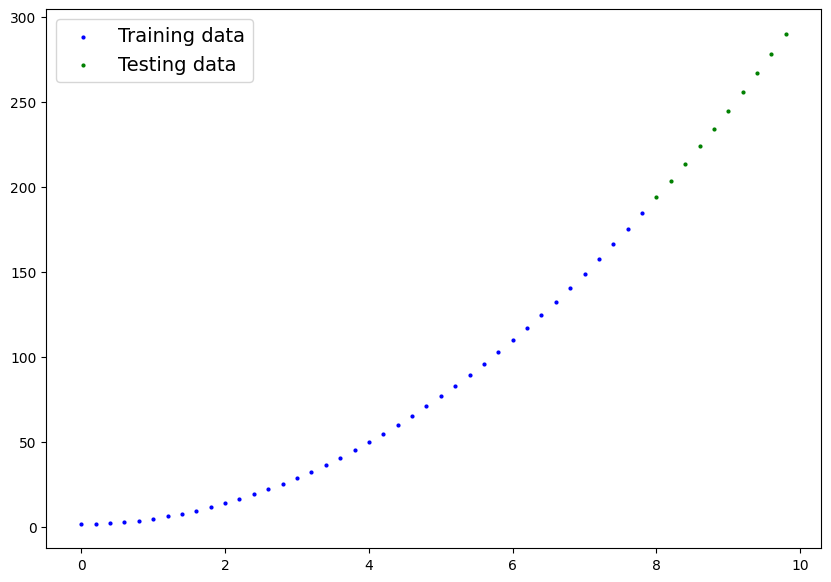

In [37]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

In [38]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [39]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created
# list(model_0.parameters())

In [40]:
print(model_0.linear.weight.dtype)
print(model_0.linear.bias.dtype)

torch.float32
torch.float32


In [41]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579]])

- As the name suggests, `torch.inference_mode()` is used when using a model for `inference` (making predictions).
    - it turns off gradient tracking (which is not necessary for inference/prediction)
    

In [42]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579],
        [7.7109],
        [7.8638],
        [8.0167],
        [8.1696],
        [8.3225]])


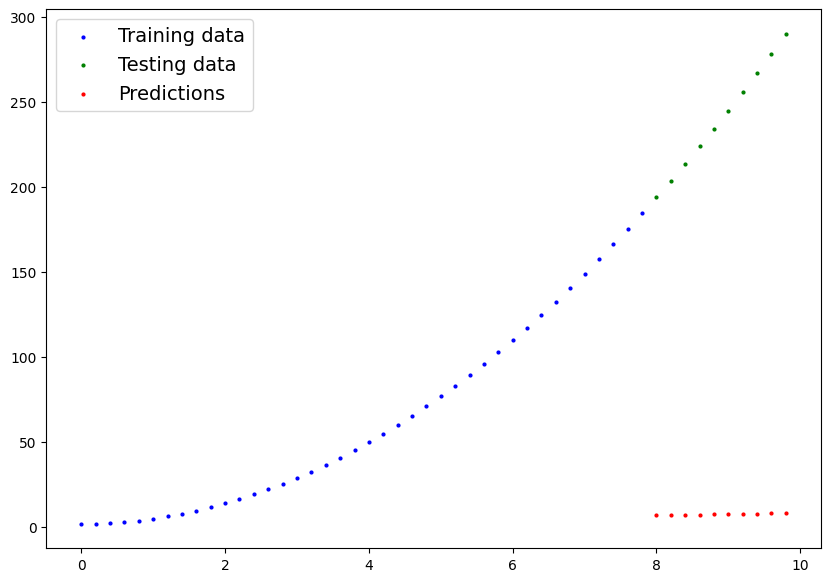

In [43]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [44]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

MAE is the average absolute difference between true values (y_i) and predictions (ŷ_i).
$$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert$$

- Lower MAE → better fit.
- More robust to outliers than MSE (no squaring).

Here, our optimizer is SGD which is short for Stochastic Gradient Descent (SGD). 

The reason for the name: 
- the gradient is computed from a stochastic (random) sample of the training data rather than the entire dataset

### Model Training

In [45]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 2000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 59.80829620361328 | MAE Test Loss: 232.6284942626953 
Epoch: 10 | MAE Train Loss: 58.187294006347656 | MAE Test Loss: 229.0574951171875 
Epoch: 20 | MAE Train Loss: 56.56629180908203 | MAE Test Loss: 225.4864959716797 
Epoch: 30 | MAE Train Loss: 54.945289611816406 | MAE Test Loss: 221.91549682617188 
Epoch: 40 | MAE Train Loss: 53.32429122924805 | MAE Test Loss: 218.34451293945312 
Epoch: 50 | MAE Train Loss: 51.70328903198242 | MAE Test Loss: 214.7734832763672 
Epoch: 60 | MAE Train Loss: 50.12068557739258 | MAE Test Loss: 211.242919921875 
Epoch: 70 | MAE Train Loss: 48.60227584838867 | MAE Test Loss: 207.7753448486328 
Epoch: 80 | MAE Train Loss: 47.13697052001953 | MAE Test Loss: 204.36285400390625 
Epoch: 90 | MAE Train Loss: 45.713233947753906 | MAE Test Loss: 200.9970703125 
Epoch: 100 | MAE Train Loss: 44.328060150146484 | MAE Test Loss: 197.67660522460938 
Epoch: 110 | MAE Train Loss: 42.97723388671875 | MAE Test Loss: 194.39744567871094 
Epoch: 120

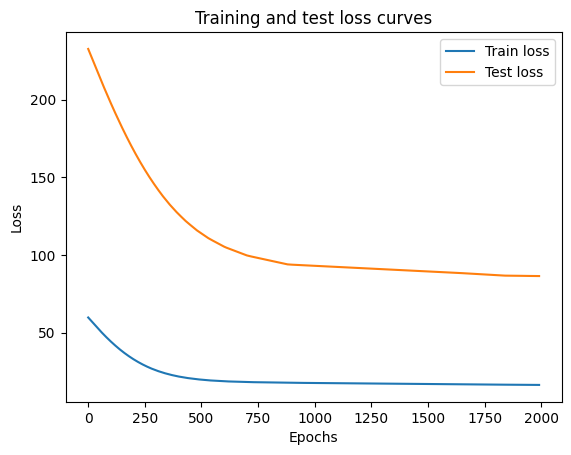

In [46]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [47]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'linear.weight': tensor([[17.6071]]), 'linear.bias': tensor([-2.5220])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


*This is the whole idea of machine learning and deep learning, there are some ideal values that describe our data and rather than figuring them out by hand, we can train a model to figure them out programmatically.*

## Analysis of linear-regression-data1.csv

In [48]:
# Load linear-regression-data1.csv
df1 = pd.read_csv(r'../dataset/linear-regression-data1.csv')
df1.head(5)

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356


In [49]:
# Convert to tensors
X1 = torch.tensor(df1['x'].values, dtype=torch.float32).unsqueeze(1)
y1 = torch.tensor(df1['y'].values, dtype=torch.float32).unsqueeze(1)

# Split data
train_split1 = int(0.8 * len(X1))
X_train1, y_train1 = X1[:train_split1], y1[:train_split1]
X_test1, y_test1 = X1[train_split1:], y1[train_split1:]

print(f"Dataset shape: {X1.shape}")
print(f"Train: {len(X_train1)}, Test: {len(X_test1)}")

Dataset shape: torch.Size([50, 1])
Train: 40, Test: 10


In [50]:
# Create new model instance for linear-regression-data1.csv
model_1 = LinearRegressionNN()
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

# Training
torch.manual_seed(42)
epochs = 1000
train_loss_values1 = []
test_loss_values1 = []
epoch_count1 = []

for epoch in range(epochs):
    model_1.train()
    y_pred = model_1(X_train1)
    loss = loss_fn(y_pred, y_train1)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test1)
        test_loss = loss_fn(test_pred, y_test1.type(torch.float))
        
        if epoch % 100 == 0:
            epoch_count1.append(epoch)
            train_loss_values1.append(loss.detach().numpy())
            test_loss_values1.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Train Loss: 0.5552 | Test Loss: 0.5740
Epoch: 100 | Train Loss: 0.0062 | Test Loss: 0.0141
Epoch: 200 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 300 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 400 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 500 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 600 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 700 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 800 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 900 | Train Loss: 0.0013 | Test Loss: 0.0138


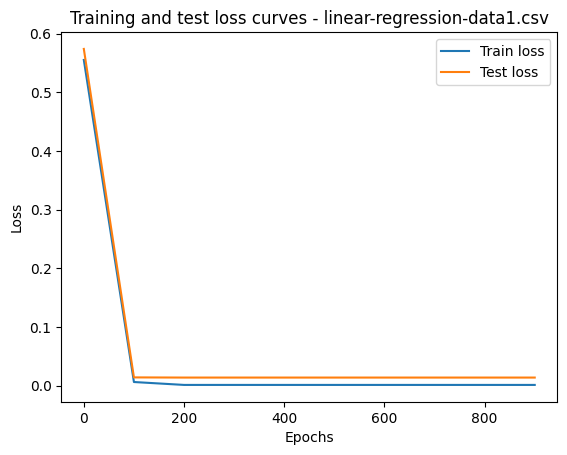

In [51]:
# Plot loss curves for linear-regression-data1.csv
plt.plot(epoch_count1, train_loss_values1, label="Train loss")
plt.plot(epoch_count1, test_loss_values1, label="Test loss")
plt.title("Training and test loss curves - linear-regression-data1.csv")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [52]:
# Check learned parameters for linear-regression-data1.csv
print("Learned parameters for linear-regression-data1.csv:")
print(model_1.state_dict())
print("\nExpected: weight ≈ 0.7, bias ≈ 0.3")

Learned parameters for linear-regression-data1.csv:
OrderedDict({'linear.weight': tensor([[0.6968]]), 'linear.bias': tensor([0.3025])})

Expected: weight ≈ 0.7, bias ≈ 0.3


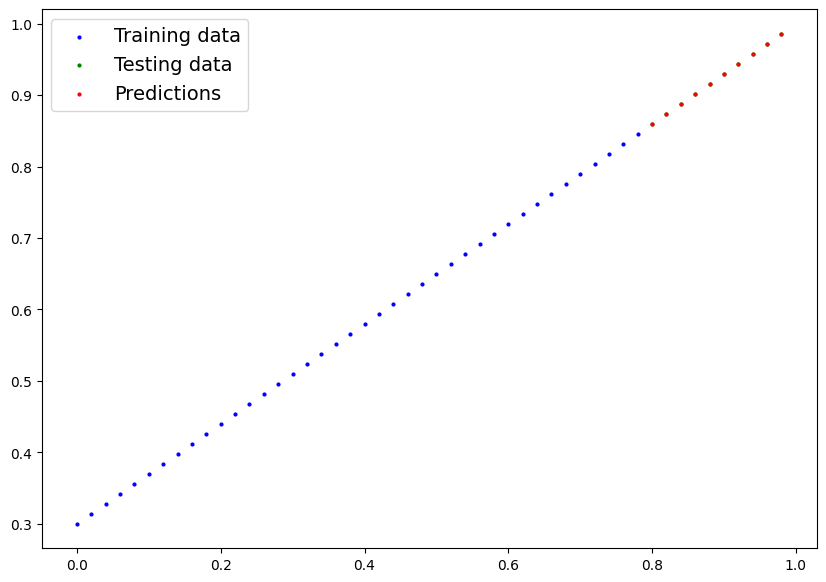

In [53]:
# Make predictions and plot for linear-regression-data1.csv
model_1.eval()
with torch.inference_mode():
    y_preds1 = model_1(X_test1)
plot_predictions(X_train1, y_train1, X_test1, y_test1, predictions=y_preds1)

## Analysis of assignment-data2.csv

In [54]:
# Load assignment-data2.csv
df2 = pd.read_csv(r'../dataset/assignment-data2.csv')
df2.head(5)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00


In [55]:
# Convert to tensors
X2 = torch.tensor(df2['x'].values, dtype=torch.float32).unsqueeze(1)
y2 = torch.tensor(df2['y'].values, dtype=torch.float32).unsqueeze(1)

# Split data
train_split2 = int(0.8 * len(X2))
X_train2, y_train2 = X2[:train_split2], y2[:train_split2]
X_test2, y_test2 = X2[train_split2:], y2[train_split2:]

print(f"Dataset shape: {X2.shape}")
print(f"Train: {len(X_train2)}, Test: {len(X_test2)}")

Dataset shape: torch.Size([99, 1])
Train: 79, Test: 20


In [56]:
# Create new model instance for assignment-data2.csv
model_2 = LinearRegressionNN()
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

# Training
torch.manual_seed(42)
epochs = 1000
train_loss_values2 = []
test_loss_values2 = []
epoch_count2 = []

for epoch in range(epochs):
    model_2.train()
    y_pred = model_2(X_train2)
    loss = loss_fn(y_pred, y_train2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test2)
        test_loss = loss_fn(test_pred, y_test2.type(torch.float))
        
        if epoch % 100 == 0:
            epoch_count2.append(epoch)
            train_loss_values2.append(loss.detach().numpy())
            test_loss_values2.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Train Loss: 175.2991 | Test Loss: 440.4581
Epoch: 100 | Train Loss: 170.4003 | Test Loss: 455.2975
Epoch: 200 | Train Loss: 165.6878 | Test Loss: 470.0687
Epoch: 300 | Train Loss: 161.1707 | Test Loss: 484.6289
Epoch: 400 | Train Loss: 156.8606 | Test Loss: 498.9236
Epoch: 500 | Train Loss: 152.7918 | Test Loss: 512.8658
Epoch: 600 | Train Loss: 148.9881 | Test Loss: 526.3882
Epoch: 700 | Train Loss: 145.4379 | Test Loss: 539.4781
Epoch: 800 | Train Loss: 142.1521 | Test Loss: 552.0865
Epoch: 900 | Train Loss: 139.1673 | Test Loss: 564.1008


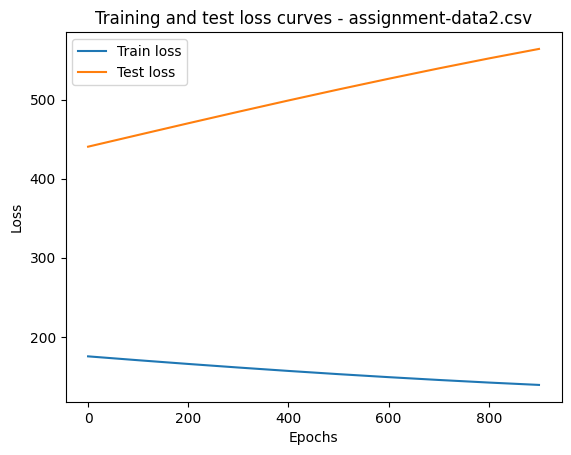

In [57]:
# Plot loss curves for assignment-data2.csv
plt.plot(epoch_count2, train_loss_values2, label="Train loss")
plt.plot(epoch_count2, test_loss_values2, label="Test loss")
plt.title("Training and test loss curves - assignment-data2.csv")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [58]:
# Check learned parameters for assignment-data2.csv
print("Learned parameters for assignment-data2.csv:")
print(model_2.state_dict())
print("\nNote: This dataset has a quadratic relationship (y ≈ x² + 1)")
print("The linear model cannot capture this nonlinear pattern.")

Learned parameters for assignment-data2.csv:
OrderedDict({'linear.weight': tensor([[-17.3084]]), 'linear.bias': tensor([8.4690])})

Note: This dataset has a quadratic relationship (y ≈ x² + 1)
The linear model cannot capture this nonlinear pattern.


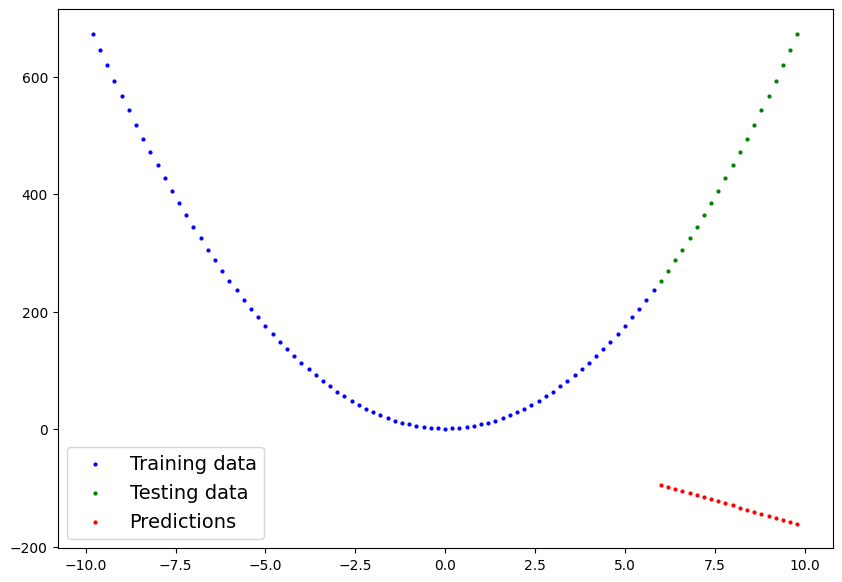

In [59]:
# Make predictions and plot for assignment-data2.csv
model_2.eval()
with torch.inference_mode():
    y_preds2 = model_2(X_test2)
plot_predictions(X_train2, y_train2, X_test2, y_test2, predictions=y_preds2)

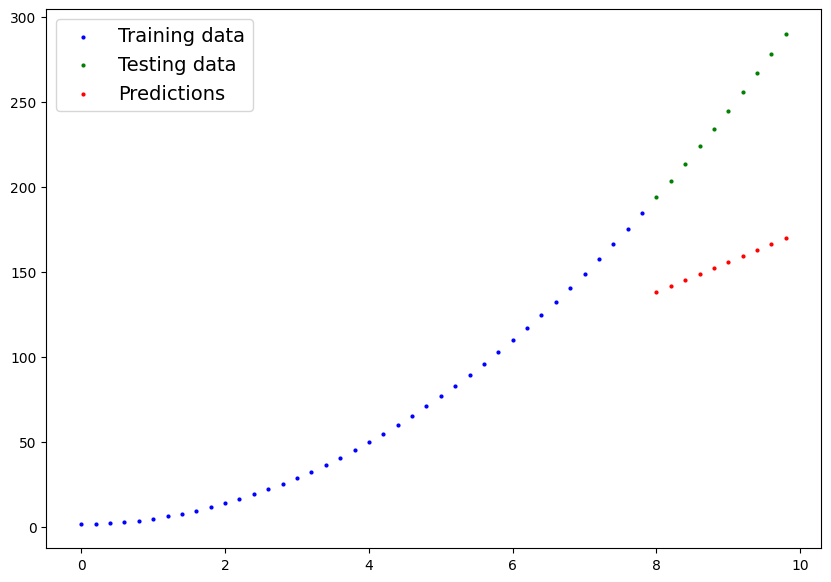

In [60]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Dataset Compatibility Analysis

### linear-regression-data1.csv
- **Compatible**: YES
- **Reason**: This dataset has a linear relationship. The model architecture is appropriate.

### assignment-data.csv
- **Compatible**: NO
- **Reason**: This dataset has a quadratic relationship (y ≈ x² + 2). The linear model cannot capture the nonlinear pattern.

### assignment-data2.csv
- **Compatible**: NO
- **Reason**: This dataset has a quadratic relationship (y ≈ x² + 1). The linear model cannot capture the nonlinear pattern.